In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 5")

## Section 1 : Import Libraries

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.preprocessing       import LabelEncoder, StandardScaler
from sklearn.linear_model        import LogisticRegression
from sklearn.tree                import DecisionTreeClassifier
from sklearn.ensemble            import RandomForestClassifier
from sklearn.svm                 import SVC

In [5]:
from sklearn.model_selection     import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics             import accuracy_score, classification_report
from sklearn.inspection          import permutation_importance
from sklearn.impute              import SimpleImputer

In [6]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded')

Libraries loaded


## Section 2 : Load Data

In [7]:
df = pd.read_csv('osteoporosis.csv')
df.drop(columns=['ID'], inplace=True, errors='ignore')

In [8]:
print(f'Shape: {df.shape}')
df.head()

Shape: (1958, 16)


,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


## Section 3 : Preprocessing

#### ── 3.1 Handle Missing Values ──────────────────────────────────────

In [9]:
# 3.1 Handle Missing Values
print('Missing values before:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before:
Alcohol Consumption    988
Medical Conditions     647
Medications            985
dtype: int64


In [10]:
# Fill numerical with median
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [11]:
print('\nMissing values after:', df.isnull().sum().sum())


Missing values after: 0


#### ── 3.2 Save target BEFORE any encoding ──────────────────────────────────────
(prevents NaN corruption)

In [12]:
y_raw = df['Osteoporosis'].copy()
print("Target saved. Unique values:", y_raw.unique())
print("NaN count:", y_raw.isnull().sum())

Target saved. Unique values: [1 0]
NaN count: 0


#### ── 3.2 Label Encoding for Binary/Ordinal Features ──────────────────

In [13]:
# Binary mappings
binary_map  = {'Yes': 1, 'No': 0}
binary_cols = ['Family History', 'Smoking', 'Alcohol Consumption', 'Prior Fractures']

In [14]:
for col in binary_cols:
    df[col] = df[col].map(binary_map)

In [15]:
# Ordinal mappings
df['Hormonal Changes']  = df['Hormonal Changes'].map({'Normal': 0, 'Postmenopausal': 1})
df['Body Weight']       = df['Body Weight'].map({'Underweight': 0, 'Normal': 1, 'Overweight': 2})
df['Calcium Intake']    = df['Calcium Intake'].map({'Low': 0, 'Adequate': 1})
df['Vitamin D Intake']  = df['Vitamin D Intake'].map({'Insufficient': 0, 'Sufficient': 1})
df['Physical Activity'] = df['Physical Activity'].map({'Sedentary': 0, 'Moderate': 1, 'Active': 2})
df['Gender']            = df['Gender'].map({'Female': 1, 'Male': 0})

In [16]:
# One-Hot Encoding for nominal features
df = pd.get_dummies(df, columns=['Race/Ethnicity', 'Medical Conditions', 'Medications'], drop_first=True)

In [17]:
# Encode target column in df (for reference only — y uses y_raw)
df['Osteoporosis'] = df['Osteoporosis'].map({'Yes': 1, 'No': 0})

In [18]:
print('Encoding complete')
print(f'Shape after encoding: {df.shape}')

Encoding complete
Shape after encoding: (1958, 16)


## Section 4 : Feature Engineering 

#### ── 4.1 Feature Engineering ──────────────────────────────────────────

In [19]:
df['Nutrient_Deficiency'] = ((df['Calcium Intake'] == 0) | (df['Vitamin D Intake'] == 0)).astype(int)
df['Lifestyle_Risk']      = df['Smoking'] + df['Alcohol Consumption']
df['Age_Group']           = pd.cut(df['Age'], bins=[0, 40, 55, 70, 120],
                                   labels=[0, 1, 2, 3]).astype(int)
df['Hormonal_Bone_Risk']  = df['Hormonal Changes'] * df['Family History']
 
print('Engineered features added')
print('New features: Nutrient_Deficiency, Lifestyle_Risk, Age_Group, Hormonal_Bone_Risk')

Engineered features added
New features: Nutrient_Deficiency, Lifestyle_Risk, Age_Group, Hormonal_Bone_Risk


#### ── 4.2 Prepare X, y ─────────────────────────────────────────────────

In [20]:
X = df.drop(columns=['Osteoporosis'])
 
# Use y_raw (saved before encoding) to avoid NaN corruption
y = y_raw.copy()
if y.dtype == 'object':
    y = y.str.strip().str.capitalize().map({'Yes': 1, 'No': 0})

In [21]:
# Reset index to align with X after get_dummies
y = y.reset_index(drop=True)
X = X.reset_index(drop=True)
 
print(f'Features (X): {X.shape[1]} | Samples: {X.shape[0]}')
print(f'Target (y) NaN count: {y.isnull().sum()}')
print(f'Target (y) distribution:\n{y.value_counts()}')

Features (X): 19 | Samples: 1958
Target (y) NaN count: 0
Target (y) distribution:
Osteoporosis
1    979
0    979
Name: count, dtype: int64


## Section 5 : Train Test

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
# Impute any NaNs in X introduced by encoding mismatches
imputer     = SimpleImputer(strategy='most_frequent')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)
 
X_train_fe  = pd.DataFrame(X_train_imp, columns=imputer.get_feature_names_out())
X_test_fe   = pd.DataFrame(X_test_imp,  columns=imputer.get_feature_names_out())

In [24]:
#Scale features (for Logistic Regression & SVC)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fe)
X_test_scaled  = scaler.transform(X_test_fe)

In [25]:
# Save column names for later use
feature_names = list(X_train_fe.columns)

In [26]:
print(f'Train set : {X_train.shape[0]} samples')
print(f'Test set  : {X_test.shape[0]} samples')
print(f'Class balance (train): {y_train.value_counts().to_dict()}')
print(f'NaNs in X_train_fe    : {X_train_fe.isnull().sum().sum()}')
print(f'NaNs in X_train_scaled: {np.isnan(X_train_scaled).sum()}')

Train set : 1566 samples
Test set  : 392 samples
Class balance (train): {0: 783, 1: 783}
NaNs in X_train_fe    : 0
NaNs in X_train_scaled: 0


In [27]:
# ── Check actual values in Osteoporosis column BEFORE mapping ──
print("Unique values in 'Osteoporosis':", df['Osteoporosis'].unique())
print("Dtype:", df['Osteoporosis'].dtype)

Unique values in 'Osteoporosis': [nan]
Dtype: float64


## sEction 6 : Baseline Model

In [28]:
RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [29]:
baseline_configs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(random_state=RANDOM_STATE),
    'SVC':                 SVC(probability=True, random_state=RANDOM_STATE),
}

In [30]:
SCALED_MODELS = {'Logistic Regression', 'SVC'}
MODEL_COLORS  = {
    'Logistic Regression': '#3498DB',
    'Decision Tree':       '#E67E22',
    'Random Forest':       '#2ECC71',
    'SVC':                 '#9B59B6'
}

In [31]:
def get_metrics(model, X_tr, y_tr):
    y_pred = model.predict(X_tr)
    report = classification_report(y_tr, y_pred, output_dict=True)
    return {
        'Accuracy':  round(accuracy_score(y_tr, y_pred), 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall':    round(report['1']['recall'], 4),
        'F1':        round(report['1']['f1-score'], 4),
    }
 
baseline_results  = []
fitted_baselines  = {}

In [32]:
print('Training baseline models (default params)...')
print('-' * 65)
 
for name, model in baseline_configs.items():
    X_tr = X_train_scaled if name in SCALED_MODELS else X_train_fe.values
    X_te = X_test_scaled  if name in SCALED_MODELS else X_test_fe.values
 
    cv_f1  = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1')
    model.fit(X_tr, y_train)
    fitted_baselines[name] = model
 
    m            = get_metrics(model, X_tr, y_train)
    overfit_flag = ' <-- OVERFITTING' if m['Accuracy'] - cv_f1.mean() > 0.15 else ''
 
    baseline_results.append({
        'Model':       name,
        'CV F1 Mean':  round(cv_f1.mean(), 4),
        'CV F1 Std':   round(cv_f1.std(),  4),
        **m
    })
    print(f'{name:<22} CV F1={cv_f1.mean():.4f}(+-{cv_f1.std():.4f})  '
          f'TrainAcc={m["Accuracy"]}{overfit_flag}')
 
baseline_df = (pd.DataFrame(baseline_results)
               .sort_values('CV F1 Mean', ascending=False)
               .reset_index(drop=True))
 
print('\nBaseline training complete.')
display(baseline_df)

Training baseline models (default params)...
-----------------------------------------------------------------
Logistic Regression    CV F1=0.8278(+-0.0197)  TrainAcc=0.8557
Decision Tree          CV F1=0.8692(+-0.0082)  TrainAcc=1.0
Random Forest          CV F1=0.8447(+-0.0256)  TrainAcc=1.0 <-- OVERFITTING
SVC                    CV F1=0.8261(+-0.0227)  TrainAcc=0.8602

Baseline training complete.


,Model,CV F1 Mean,CV F1 Std,Accuracy,Precision,Recall,F1
0,Decision Tree,0.8692,0.0082,1.0000,1.0000,1.0000,1.0000
1,Random Forest,0.8447,0.0256,1.0000,1.0000,1.0000,1.0000
2,Logistic Regression,0.8278,0.0197,0.8557,0.9696,0.7344,0.8358
3,SVC,0.8261,0.0227,0.8602,1.0000,0.7203,0.8374


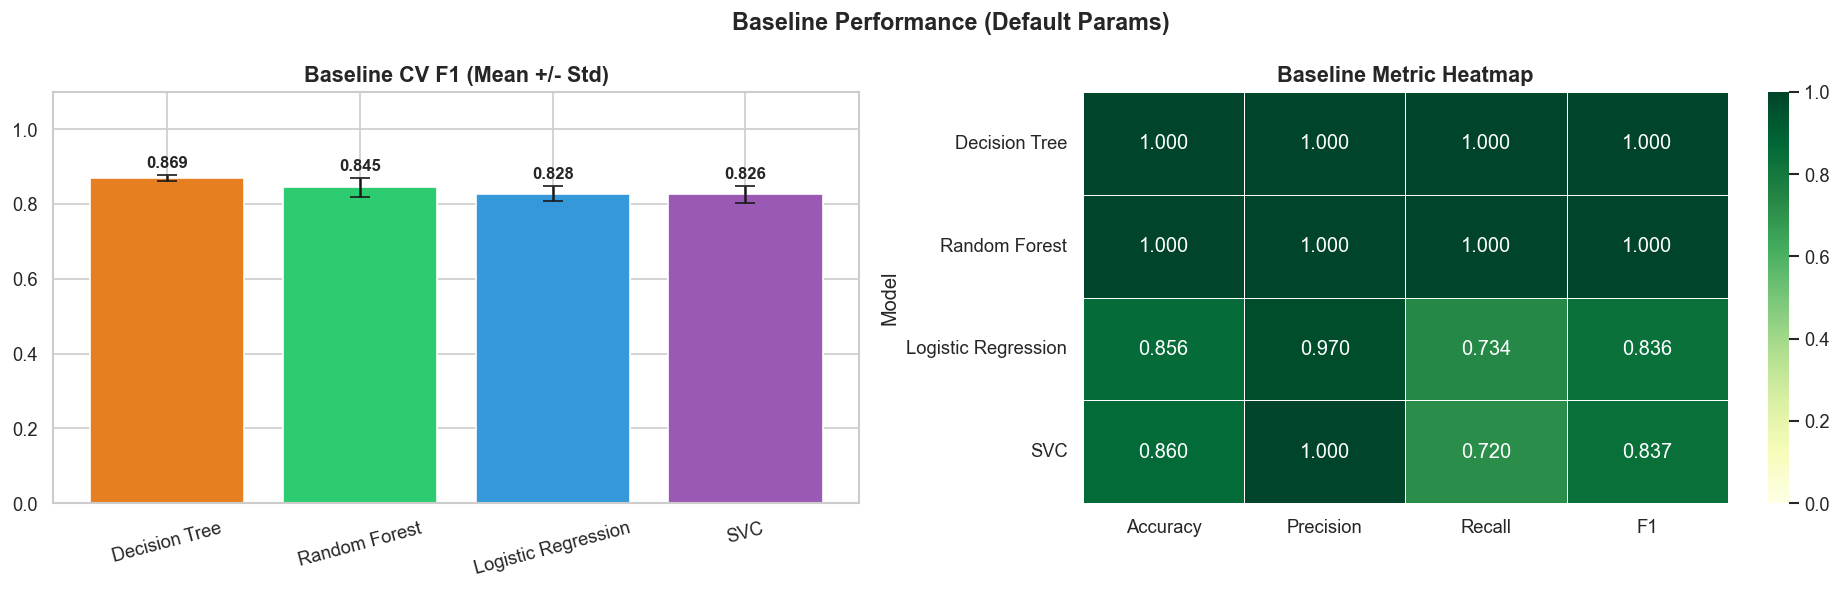

Best baseline:  Decision Tree (CV F1=0.8692)
Worst baseline: SVC (CV F1=0.8261)
Next: apply GridSearchCV to all models and check if tuning improves these scores.


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# CV F1 with error bars
mnames = baseline_df['Model'].tolist()
cols   = [MODEL_COLORS[m] for m in mnames]
axes[0].bar(mnames, baseline_df['CV F1 Mean'], yerr=baseline_df['CV F1 Std'],
            color=cols, edgecolor='white', capsize=6)
axes[0].set_title('Baseline CV F1 (Mean +/- Std)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)
for i, (m, s) in enumerate(zip(baseline_df['CV F1 Mean'], baseline_df['CV F1 Std'])):
    axes[0].text(i, m+s+0.02, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

# Metric heatmap
heat = baseline_df.set_index('Model')[['Accuracy','Precision','Recall','F1']]
sns.heatmap(heat, annot=True, fmt='.3f', cmap='YlGn', ax=axes[1],
            linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Baseline Metric Heatmap', fontsize=13, fontweight='bold')

plt.suptitle('Baseline Performance (Default Params)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best baseline:  {baseline_df.iloc[0]["Model"]} (CV F1={baseline_df.iloc[0]["CV F1 Mean"]:.4f})')
print(f'Worst baseline: {baseline_df.iloc[-1]["Model"]} (CV F1={baseline_df.iloc[-1]["CV F1 Mean"]:.4f})')
print('Next: apply GridSearchCV to all models and check if tuning improves these scores.')

## Section 7 : GridSearchCV

In [34]:
# Model definitions & hyperparameter grids
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['lbfgs', 'liblinear'],
            'penalty': ['l2']
        },
        'use_scaled': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy']
        },
        'use_scaled': False
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
            'max_features': ['sqrt', 'log2']
        },
        'use_scaled': False
    },
    'SVC': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        },
        'use_scaled': True
    }
}

print('Model configurations defined')

Model configurations defined


In [35]:
# Run GridSearchCV for each model
trained_models = {}
results_summary = []

for name, config in models_params.items():
    print(f'\n Training: {name} ...')

    X_tr = X_train_scaled if config['use_scaled'] else X_train
    X_ts = X_test_scaled  if config['use_scaled'] else X_test

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_tr, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_ts)
    acc = accuracy_score(y_test, y_pred)

    trained_models[name] = {
        'model': best_model,
        'best_params': grid.best_params_,
        'cv_f1': grid.best_score_,
        'test_acc': acc,
        'y_pred': y_pred,
        'use_scaled': config['use_scaled']
    }

    results_summary.append({
        'Model': name,
        'Best CV F1': round(grid.best_score_, 4),
        'Test Accuracy': round(acc, 4),
        'Best Params': str(grid.best_params_)
    })

    print(f'   Best CV F1:  {grid.best_score_:.4f}')
    print(f'   Test Acc:    {acc:.4f}')
    print(f'   Best Params: {grid.best_params_}')

print('\n All models trained!')


 Training: Logistic Regression ...
   Best CV F1:  0.8316
   Test Acc:    0.8291
   Best Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

 Training: Decision Tree ...
   Best CV F1:  0.9068
   Test Acc:    0.8776
   Best Params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}

 Training: Random Forest ...
   Best CV F1:  0.8456
   Test Acc:    0.8342
   Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}

 Training: SVC ...
   Best CV F1:  0.8261
   Test Acc:    0.8240
   Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

 All models trained!


## Section 8 : Results & Summary

In [36]:
results_df = pd.DataFrame(results_summary).sort_values('Best CV F1', ascending=False)
print('\n=== Model Comparison Summary ===')
display(results_df[['Model', 'Best CV F1', 'Test Accuracy']])


=== Model Comparison Summary ===


,Model,Best CV F1,Test Accuracy
1,Decision Tree,0.9068,0.8776
2,Random Forest,0.8456,0.8342
0,Logistic Regression,0.8316,0.8291
3,SVC,0.8261,0.8240


In [37]:
# Best model
best_model_name = results_df.iloc[0]['Model']
print(f'\n Best Model: {best_model_name}')


 Best Model: Decision Tree


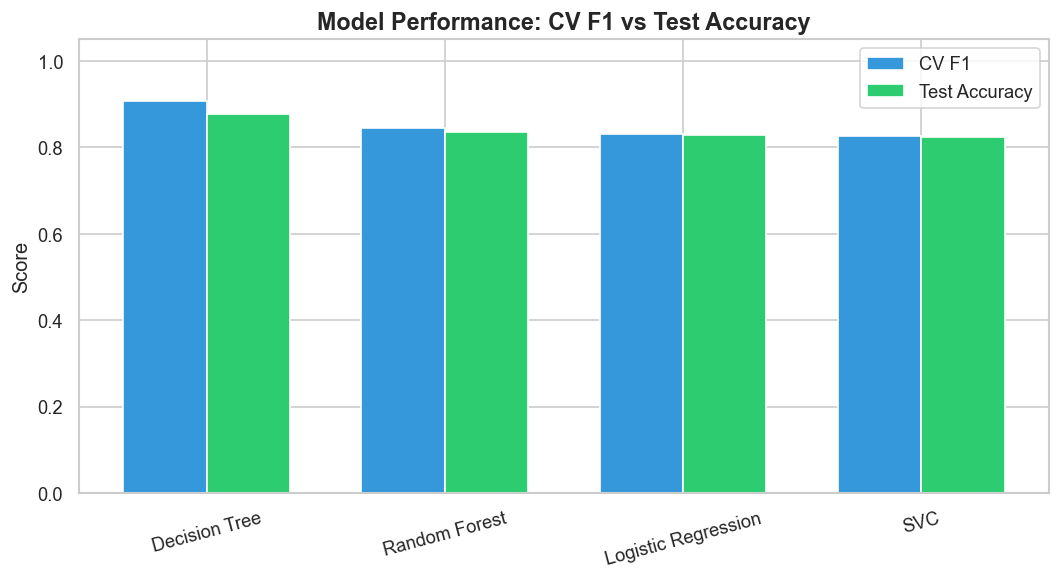

In [38]:
# Quick training accuracy chart
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
w = 0.35
ax.bar(x - w/2, results_df['Best CV F1'],   width=w, label='CV F1',        color='#3498DB', edgecolor='white')
ax.bar(x + w/2, results_df['Test Accuracy'], width=w, label='Test Accuracy', color='#2ECC71', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_title('Model Performance: CV F1 vs Test Accuracy', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

## Section 9 : Feature Importance

Model feature count    : 19
feat_names count       : 19


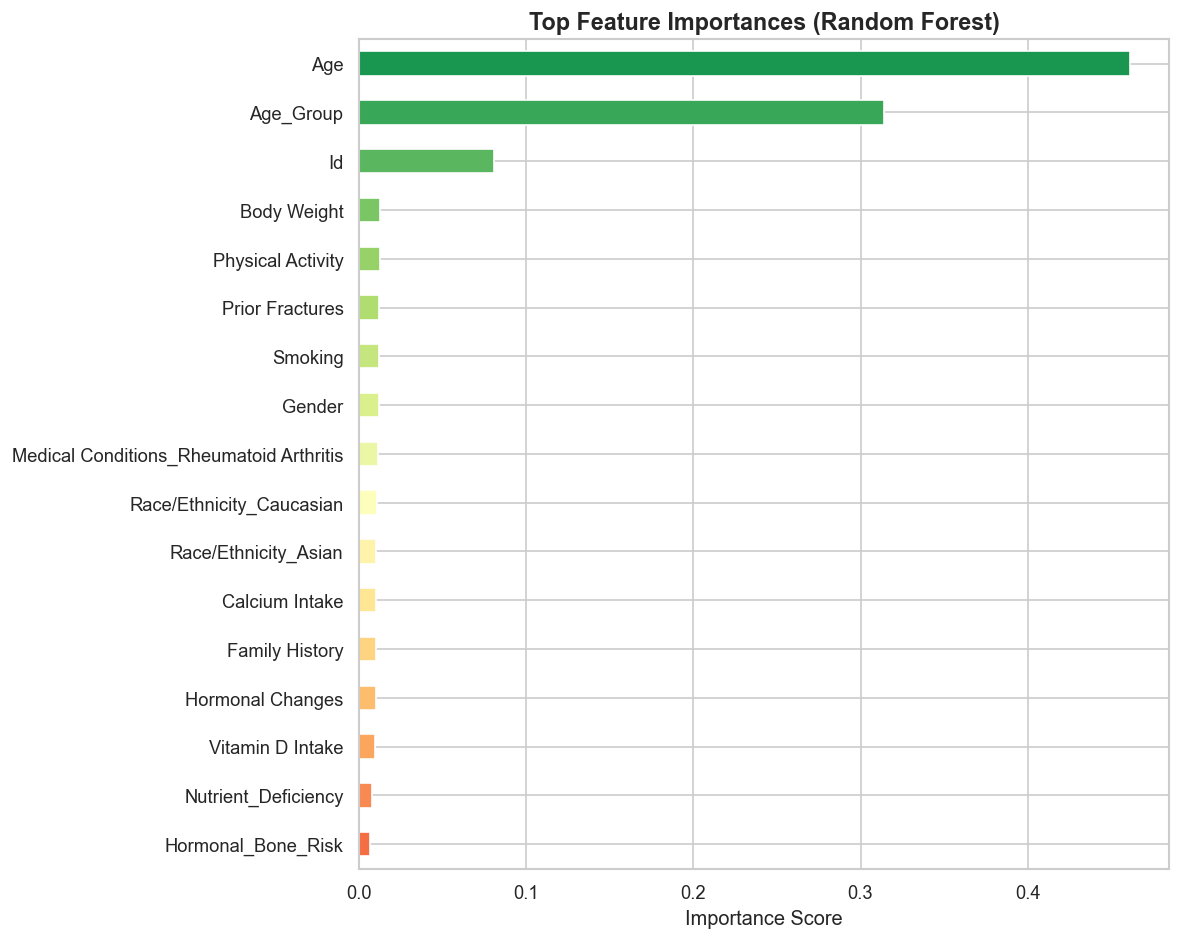

Top 10 Features:
Age                                        0.461450
Age_Group                                  0.314002
Id                                         0.080711
Body Weight                                0.012538
Physical Activity                          0.012159
Prior Fractures                            0.011844
Smoking                                    0.011539
Gender                                     0.011521
Medical Conditions_Rheumatoid Arthritis    0.011140
Race/Ethnicity_Caucasian                   0.010276
dtype: float64


In [43]:
rf_model = trained_models['Random Forest']['model']

# Get exact feature names the model was trained on
try:
    feat_names = rf_model.feature_names_in_.tolist()  # works if trained on DataFrame
except AttributeError:
    # fallback — model was trained on numpy array, reconstruct from X_train_fe
    feat_names = list(X_train_fe.columns)

print("Model feature count    :", len(rf_model.feature_importances_))
print("feat_names count       :", len(feat_names))

importances = pd.Series(rf_model.feature_importances_, index=feat_names)
importances = importances.sort_values(ascending=True).tail(17)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot/09_Feature_Importance.png', bbox_inches='tight')
plt.show()

print('Top 10 Features:')
print(importances.sort_values(ascending=False).head(10))

In [45]:
feature_names

['Id',
 'Age',
 'Gender',
 'Hormonal Changes',
 'Family History',
 'Body Weight',
 'Calcium Intake',
 'Vitamin D Intake',
 'Physical Activity',
 'Smoking',
 'Prior Fractures',
 'Race/Ethnicity_Asian',
 'Race/Ethnicity_Caucasian',
 'Medical Conditions_Rheumatoid Arthritis',
 'Nutrient_Deficiency',
 'Age_Group',
 'Hormonal_Bone_Risk']

In [42]:
print("feature_importances_ length:", len(rf_model.feature_importances_))
print("X_train_fe columns length  :", len(X_train_fe.columns))
print("X_train_fe columns         :", list(X_train_fe.columns))

feature_importances_ length: 19
X_train_fe columns length  : 17
X_train_fe columns         : ['Id', 'Age', 'Gender', 'Hormonal Changes', 'Family History', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Prior Fractures', 'Race/Ethnicity_Asian', 'Race/Ethnicity_Caucasian', 'Medical Conditions_Rheumatoid Arthritis', 'Nutrient_Deficiency', 'Age_Group', 'Hormonal_Bone_Risk']


## Section 10 : Save Models

In [44]:
os.makedirs('models', exist_ok=True)

In [45]:
# Save all models
for name, info in trained_models.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(info['model'], f'models/{fname}.pkl')

In [46]:
# Save scaler & feature names
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(feature_names, 'models/feature_names.pkl')

['models/feature_names.pkl']

In [47]:
# Save test data for NB3
np.save('models/X_test.npy', X_test.values)
np.save('models/X_test_scaled.npy', X_test_scaled)
np.save('models/y_test.npy', y_test.values)

In [48]:
# Save results
results_df.to_csv('models/training_results.csv', index=False)

print('All models and artifacts saved to /models/ ')
print('\nSaved files:')
for f in os.listdir('models'):
    print(f'  • {f}')

All models and artifacts saved to /models/ 

Saved files:
  • decision_tree.pkl
  • feature_names.pkl
  • logistic_regression.pkl
  • random_forest.pkl
  • scaler.pkl
  • svc.pkl
  • training_results.csv
  • X_test.npy
  • X_test_scaled.npy
  • y_test.npy


In [49]:
print('=' * 60)
print('   NB2 COMPLETE  — Proceed to NB3: Model Evaluation')
print('=' * 60)
print(f'\nBest Model: {best_model_name}')
print(f'CV F1:       {results_df.iloc[0]["Best CV F1"]:.4f}')
print(f'Test Acc:    {results_df.iloc[0]["Test Accuracy"]:.4f}')

   NB2 COMPLETE  — Proceed to NB3: Model Evaluation

Best Model: Decision Tree
CV F1:       0.9068
Test Acc:    0.8776
